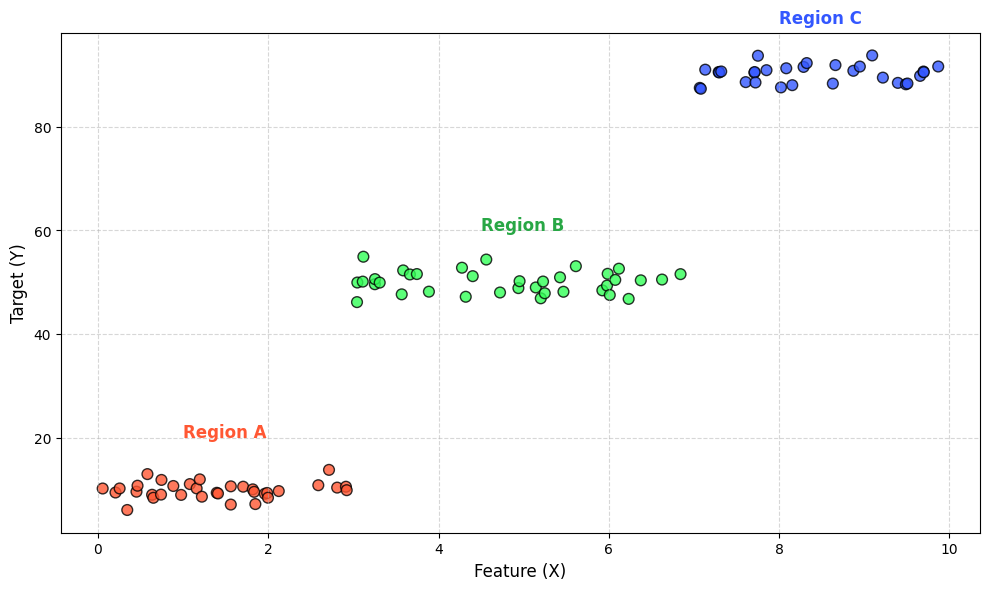

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
N = 100
X = np.sort(np.random.rand(N, 1) * 10, axis=0)

# 2. Define regions and colors
# Region 1: X < 3  (Red)
# Region 2: 3 <= X < 7 (Green)
# Region 3: X >= 7 (Blue)

colors = []
y_values = []

for xi in X:
    if xi < 3:
        colors.append('#FF5733') # Vivid Orange/Red
        y_values.append(10 + np.random.normal(0, 2))
    elif xi < 7:
        colors.append('#33FF57') # Bright Green
        y_values.append(50 + np.random.normal(0, 2))
    else:
        colors.append('#3357FF') # Royal Blue
        y_values.append(90 + np.random.normal(0, 2))

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Scatter plot using the 'colors' list we just created
plt.scatter(X, y_values, c=colors, edgecolors='black', s=60, alpha=0.8)

# Add clear labels for the slide
plt.text(1, 20, 'Region A', fontsize=12, fontweight='bold', color='#FF5733')
plt.text(4.5, 60, 'Region B', fontsize=12, fontweight='bold', color='#28a745')
plt.text(8, 100, 'Region C', fontsize=12, fontweight='bold', color='#3357FF')

plt.xlabel('Feature (X)', fontsize=12)
plt.ylabel('Target (Y)', fontsize=12)
#plt.title('Step 1: Easily Separable Data for a Decision Tree', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

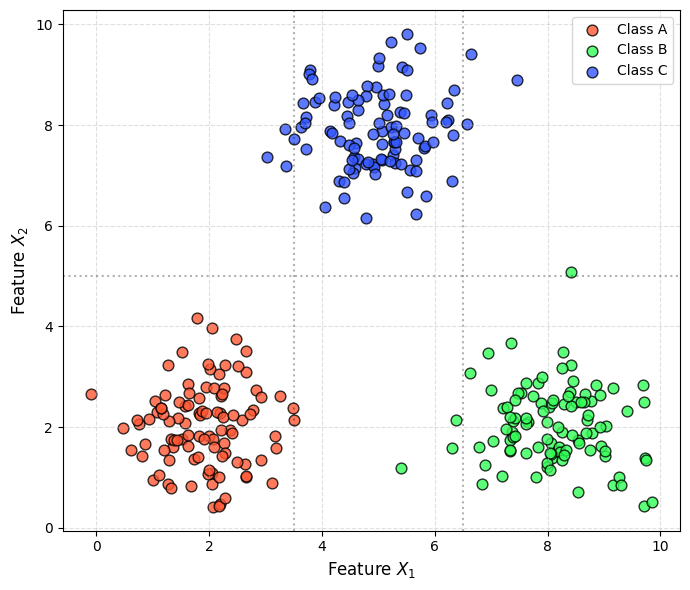

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Generate 3 distinct clusters (easily separable)
# centers defines where the 'islands' are located in (X1, X2) space
X, y = make_blobs(n_samples=300, centers=[[2, 2], [8, 2], [5, 8]], 
                  cluster_std=0.8, random_state=42)

# 2. Define colors for our 3 classes
colors = ['#FF5733', '#33FF57', '#3357FF'] # Red-Orange, Green, Blue
class_names = ['Class A', 'Class B', 'Class C']

# 3. Create the Plot
plt.figure(figsize=(7, 6))

for i, color in enumerate(colors):
    # Filter points belonging to each class
    mask = (y == i)
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=class_names[i], 
                edgecolors='black', s=60, alpha=0.8)

# Add Slide Annotations
#plt.title('Step 1: Easily Separable Classification (Ideal for 1 Tree)', fontsize=15)
plt.xlabel('Feature $X_1$', fontsize=12)
plt.ylabel('Feature $X_2$', fontsize=12)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)

# Optional: Draw the "Logic" lines a tree might find
plt.axvline(x=3.5, color='black', linestyle=':', alpha=0.3) # Split 1
plt.axvline(x=6.5, color='black', linestyle=':', alpha=0.3) # Split 2
plt.axhline(y=5, color='black', linestyle=':', alpha=0.3)    # Split 3

plt.tight_layout()
# Save the file. You can use .png, .jpg, .pdf, or .svg
plt.savefig('decision_tree_data.png', dpi=300, bbox_inches='tight')

plt.show()

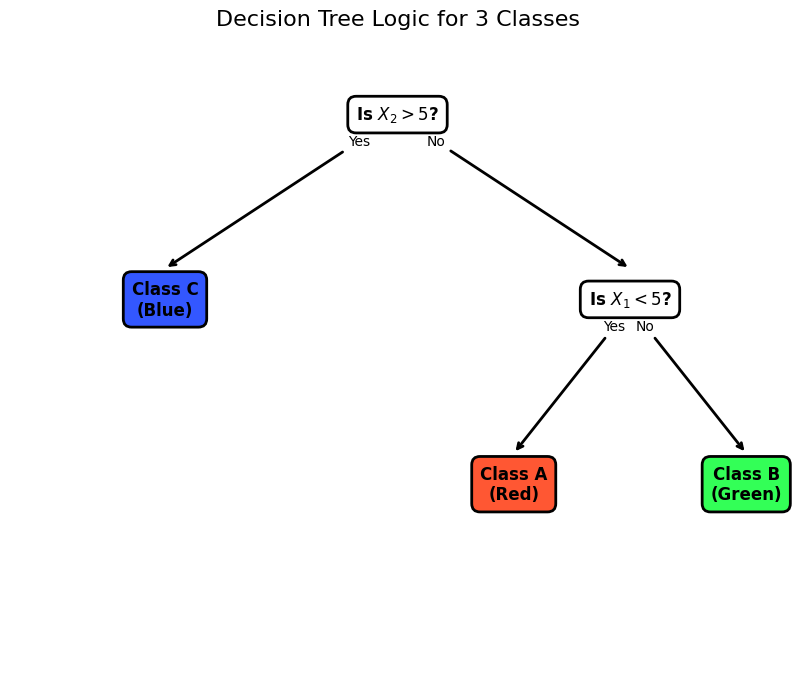

In [10]:
import matplotlib.pyplot as plt

def draw_tree():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define styles
    node_style = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=2)
    leaf_style_A = dict(boxstyle="round,pad=0.5", fc="#FF5733", ec="black", lw=2) # Red
    leaf_style_B = dict(boxstyle="round,pad=0.5", fc="#33FF57", ec="black", lw=2) # Green
    leaf_style_C = dict(boxstyle="round,pad=0.5", fc="#3357FF", ec="black", lw=2) # Blue
    arrow_props = dict(arrowstyle="->", lw=2)

    # Helper function to draw nodes
    def draw_node(text, x, y, style):
        ax.text(x, y, text, ha="center", va="center", bbox=style, fontsize=12, fontweight='bold')

    # 1. Root Node
    draw_node("Is $X_2 > 5$?", 0.5, 0.9, node_style)
    
    # 2. Level 2 Nodes
    draw_node("Class C\n(Blue)", 0.2, 0.6, leaf_style_C) # Left branch of Root
    draw_node("Is $X_1 < 5$?", 0.8, 0.6, node_style)    # Right branch of Root
    
    # 3. Level 3 Leaves (under the second split)
    draw_node("Class A\n(Red)", 0.65, 0.3, leaf_style_A) # Left branch of Split 2
    draw_node("Class B\n(Green)", 0.95, 0.3, leaf_style_B) # Right branch of Split 2

    # Draw Arrows & Labels
    # Root to Class C (Left = Yes)
    ax.annotate("Yes", xy=(0.2, 0.65), xytext=(0.45, 0.85), arrowprops=arrow_props, ha='center')
    # Root to Split 2 (Right = No)
    ax.annotate("No", xy=(0.8, 0.65), xytext=(0.55, 0.85), arrowprops=arrow_props, ha='center')
    
    # Split 2 to Class A (Left = Yes)
    ax.annotate("Yes", xy=(0.65, 0.35), xytext=(0.78, 0.55), arrowprops=arrow_props, ha='center')
    # Split 2 to Class B (Right = No)
    ax.annotate("No", xy=(0.95, 0.35), xytext=(0.82, 0.55), arrowprops=arrow_props, ha='center')

    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title("Decision Tree Logic for 3 Classes", fontsize=16, pad=20)
    
    plt.savefig('decision_tree_logic.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_tree()

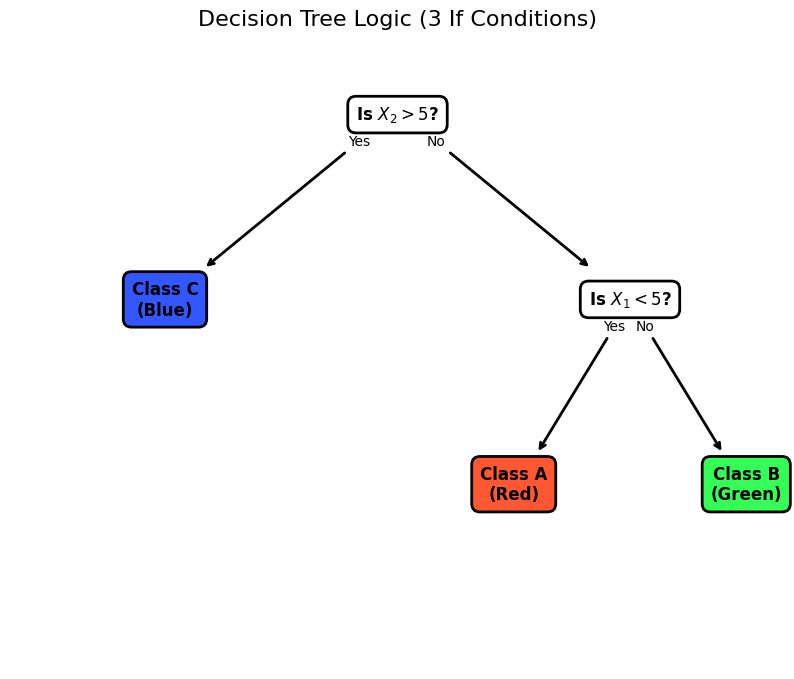

In [12]:
import matplotlib.pyplot as plt

def draw_tree_short_arrows():
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Define styles
    node_style = dict(boxstyle="round,pad=0.5", fc="white", ec="black", lw=2)
    leaf_style_A = dict(boxstyle="round,pad=0.5", fc="#FF5733", ec="black", lw=2) # Red
    leaf_style_B = dict(boxstyle="round,pad=0.5", fc="#33FF57", ec="black", lw=2) # Green
    leaf_style_C = dict(boxstyle="round,pad=0.5", fc="#3357FF", ec="black", lw=2) # Blue
    arrow_props = dict(arrowstyle="->", lw=2)

    # Helper function to draw nodes
    def draw_node(text, x, y, style):
        ax.text(x, y, text, ha="center", va="center", bbox=style, fontsize=12, fontweight='bold')

    # Coordinates for nodes
    root_y = 0.9
    level2_y = 0.6
    level3_y = 0.3
    
    # 1. Root Node
    draw_node("Is $X_2 > 5$?", 0.5, root_y, node_style)
    
    # 2. Level 2 Nodes
    draw_node("Class C\n(Blue)", 0.2, level2_y, leaf_style_C) 
    draw_node("Is $X_1 < 5$?", 0.8, level2_y, node_style)    
    
    # 3. Level 3 Leaves
    draw_node("Class A\n(Red)", 0.65, level3_y, leaf_style_A) 
    draw_node("Class B\n(Green)", 0.95, level3_y, leaf_style_B) 

    # --- Draw Shortened Arrows ---
    # Using specific xy and xytext to shorten the lines

    # Root to Class C (Yes)
    ax.annotate("Yes", xy=(0.25, level2_y + 0.05), xytext=(0.45, root_y - 0.05), arrowprops=arrow_props, ha='center')
    
    # Root to Split 2 (No)
    ax.annotate("No", xy=(0.75, level2_y + 0.05), xytext=(0.55, root_y - 0.05), arrowprops=arrow_props, ha='center')
    
    # Split 2 to Class A (Yes)
    ax.annotate("Yes", xy=(0.68, level3_y + 0.05), xytext=(0.78, level2_y - 0.05), arrowprops=arrow_props, ha='center')
    
    # Split 2 to Class B (No)
    ax.annotate("No", xy=(0.92, level3_y + 0.05), xytext=(0.82, level2_y - 0.05), arrowprops=arrow_props, ha='center')

    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.title("Decision Tree Logic (3 If Conditions)", fontsize=16, pad=20)
    
    plt.savefig('decision_tree_logic_short.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_tree_short_arrows()

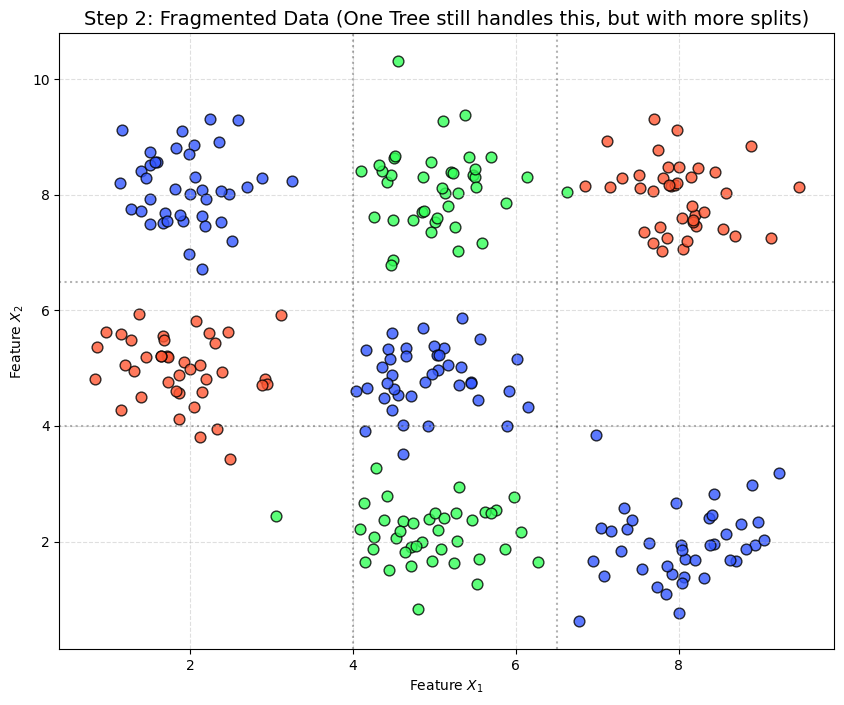

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate 6 clusters (2 for each color)
np.random.seed(42)

# Coordinates for the 6 pockets
# Class A (Red): Bottom-Left, Top-Right
# Class B (Green): Top-Left, Center
# Class C (Blue): Center-Right, Bottom-Right
centers = [
    [2, 5],[8, 8], # Class A (Red)
    [5, 8], [5, 2], # Class B (Green)
    [2,8],[8, 2], [5, 5]  # Class C (Blue)
]

# Define colors and labels
class_colors = ['#FF5733', '#FF5733', '#33FF57', '#33FF57', '#3357FF', '#3357FF', '#3357FF']
labels = ['A', 'A', 'B', 'B', 'C', 'C','C']

plt.figure(figsize=(10, 8))

for i, center in enumerate(centers):
    # Generate 40 points per pocket
    x1 = np.random.normal(center[0], 0.6, 40)
    x2 = np.random.normal(center[1], 0.6, 40)
    
    plt.scatter(x1, x2, c=class_colors[i], edgecolors='black', s=60, alpha=0.8)

# Add annotations to show the "Red" diagonal
#plt.text(1, 1, "Red (A)", fontsize=12, fontweight='bold', color='#FF5733')
#plt.text(8, 9, "Red (A)", fontsize=12, fontweight='bold', color='#FF5733')

plt.title('Step 2: Fragmented Data (One Tree still handles this, but with more splits)', fontsize=14)
plt.xlabel('Feature $X_1$')
plt.ylabel('Feature $X_2$')
plt.grid(True, linestyle='--', alpha=0.4)

# Illustrate the "Boxes" a tree would draw
plt.axvline(x=4, color='black', linestyle=':', alpha=0.3)
plt.axvline(x=6.5, color='black', linestyle=':', alpha=0.3)
plt.axhline(y=4, color='black', linestyle=':', alpha=0.3)
plt.axhline(y=6.5, color='black', linestyle=':', alpha=0.3)

plt.savefig('fragmented_tree_data.png', dpi=300, bbox_inches='tight')
plt.show()

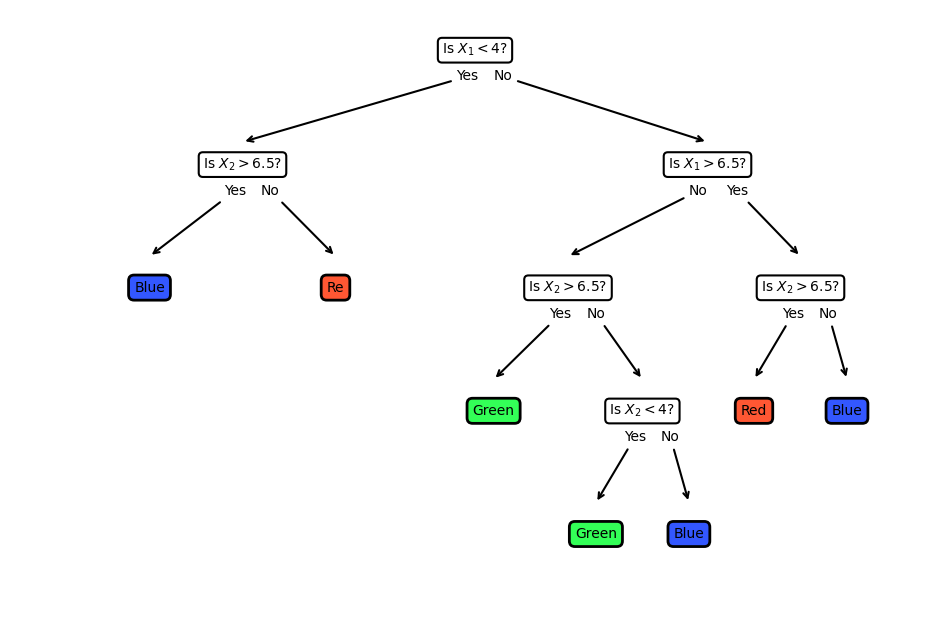

In [ ]:
import matplotlib.pyplot as plt

def draw_complex_tree():
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Styles
    node_s = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5)
    leaf_A = dict(boxstyle="round,pad=0.4", fc="#FF5733", ec="black", lw=2) # Red
    leaf_B = dict(boxstyle="round,pad=0.4", fc="#33FF57", ec="black", lw=2) # Green
    leaf_C = dict(boxstyle="round,pad=0.4", fc="#3357FF", ec="black", lw=2) # Blue
    arrow = dict(arrowstyle="->", lw=1.5)

    # 1. Root Split
    ax.text(0.5, 0.95, "Is $X_1 < 4$?", ha="center", bbox=node_s)
    
    # --- LEFT BRANCH (X1 < 4) ---
    ax.annotate("Yes", xy=(0.25, 0.85), xytext=(0.48, 0.92), arrowprops=arrow)
    ax.text(0.25, 0.82, "Is $X_2 > 6.5$?", ha="center", bbox=node_s)
    
    ax.annotate("Yes", xy=(0.15, 0.72), xytext=(0.23, 0.79), arrowprops=arrow)
    ax.text(0.15, 0.68, "Blue", ha="center", bbox=leaf_C)
    
    ax.annotate("No", xy=(0.35, 0.72), xytext=(0.27, 0.79), arrowprops=arrow)
    ax.text(0.35, 0.68, "Red", ha="center", bbox=leaf_A)

    # --- RIGHT BRANCH (X1 >= 4) ---
    ax.annotate("No", xy=(0.75, 0.85), xytext=(0.52, 0.92), arrowprops=arrow)
    ax.text(0.75, 0.82, "Is $X_1 > 6.5$?", ha="center", bbox=node_s)
    
    # Nested Right (X1 > 6.5)
    ax.annotate("Yes", xy=(0.85, 0.72), xytext=(0.77, 0.79), arrowprops=arrow)
    ax.text(0.85, 0.68, "Is $X_2 > 6.5$?", ha="center", bbox=node_s)
    
    ax.annotate("Yes", xy=(0.80, 0.58), xytext=(0.83, 0.65), arrowprops=arrow)
    ax.text(0.80, 0.54, "Red", ha="center", bbox=leaf_A)
    
    ax.annotate("No", xy=(0.90, 0.58), xytext=(0.87, 0.65), arrowprops=arrow)
    ax.text(0.90, 0.54, "Blue", ha="center", bbox=leaf_C)

    # Nested Middle (4 <= X1 <= 6.5)
    ax.annotate("No", xy=(0.6, 0.72), xytext=(0.73, 0.79), arrowprops=arrow)
    ax.text(0.6, 0.68, "Is $X_2 > 6.5$?", ha="center", bbox=node_s)
    
    ax.annotate("Yes", xy=(0.52, 0.58), xytext=(0.58, 0.65), arrowprops=arrow)
    ax.text(0.52, 0.54, "Green", ha="center", bbox=leaf_B)
    
    ax.annotate("No", xy=(0.68, 0.58), xytext=(0.62, 0.65), arrowprops=arrow)
    ax.text(0.68, 0.54, "Is $X_2 < 4$?", ha="center", bbox=node_s)
    
    ax.annotate("Yes", xy=(0.63, 0.44), xytext=(0.66, 0.51), arrowprops=arrow)
    ax.text(0.63, 0.40, "Green", ha="center", bbox=leaf_B)
    
    ax.annotate("No", xy=(0.73, 0.44), xytext=(0.70, 0.51), arrowprops=arrow)
    ax.text(0.73, 0.40, "Blue", ha="center", bbox=leaf_C)

    ax.set_ylim(0.3, 1.0)
    ax.axis('off')
    #plt.title("Fragmented Decision Tree (One Tree, Many Branches)", fontsize=14)
    plt.savefig('complex_tree_logic.png', dpi=300, bbox_inches='tight')
    plt.show()

draw_complex_tree()

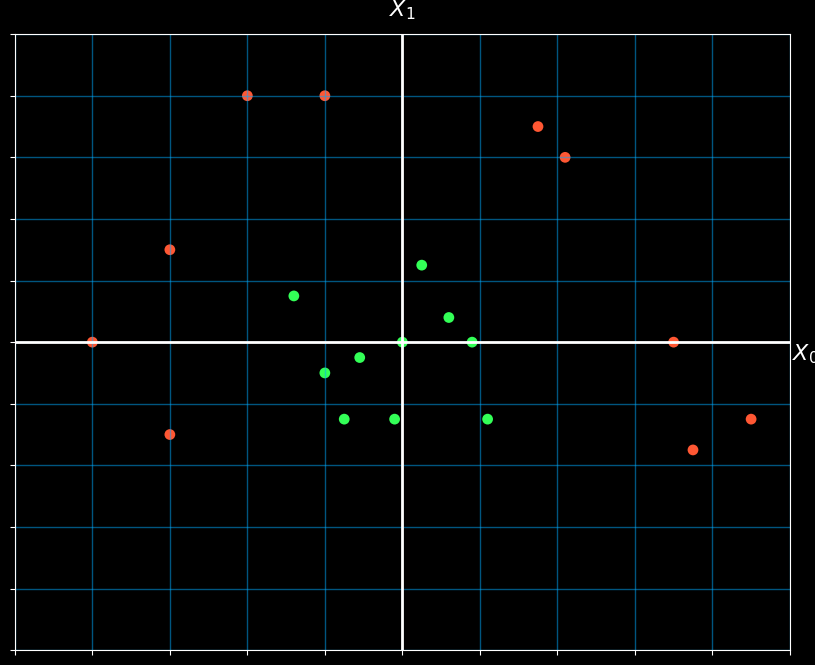

In [135]:
import matplotlib.pyplot as plt
import numpy as np

# Set the style to match the dark grid theme
plt.style.use('dark_background')

# 1. Manual estimation of coordinates from the image
green_x = [0, 0.5, 1.8, 2.2, 1.2, -0.2, -1.5, -2.8, -1.1, -2]
green_y = [0, 2.5, 0, -2.5, 0.8, -2.5, -2.5, 1.5, -0.5, -1]

red_x = [-4, -6, -6, -2, -8, 7, 7.5, 9, 3.5, 4.2]
red_y = [8, 3, -3, 8, 0, 0, -3.5, -2.5, 7, 6]

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter the points
ax.scatter(red_x, red_y, c='#FF5733', s=60, edgecolors='none', label='Class Red')
ax.scatter(green_x, green_y, c='#33FF57', s=60, edgecolors='none', label='Class Green')

# 3. Formatting
# Drawing the white "Cross" (Main Axes)
ax.axhline(0, color='white', linewidth=2, zorder=2)
ax.axvline(0, color='white', linewidth=2, zorder=2)

# Drawing the blue grid lines
ax.grid(True, color='#00aaff', linestyle='-', linewidth=1, alpha=0.5)

# Set limits
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)

# Remove numbers/ticks but keep the labels
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks(np.arange(-10, 11, 2))
ax.set_yticks(np.arange(-10, 11, 2))

# --- ADDING AXIS LABELS ---
ax.set_xlabel('$X_0$', fontsize=16, color='white', fontweight='bold', labelpad=10)
ax.set_ylabel('$X_1$', fontsize=16, color='white', fontweight='bold', labelpad=10, rotation=0)

# Position labels at the ends of the white axes lines for a more "mathematical" feel
ax.xaxis.set_label_coords(1.02, 0.5) # Move X label to the right of the line
ax.yaxis.set_label_coords(0.5, 1.02) # Move Y label to the top of the line

plt.savefig("Circular_separable_data_with_axis.png", dpi=300, bbox_inches='tight')
plt.show()

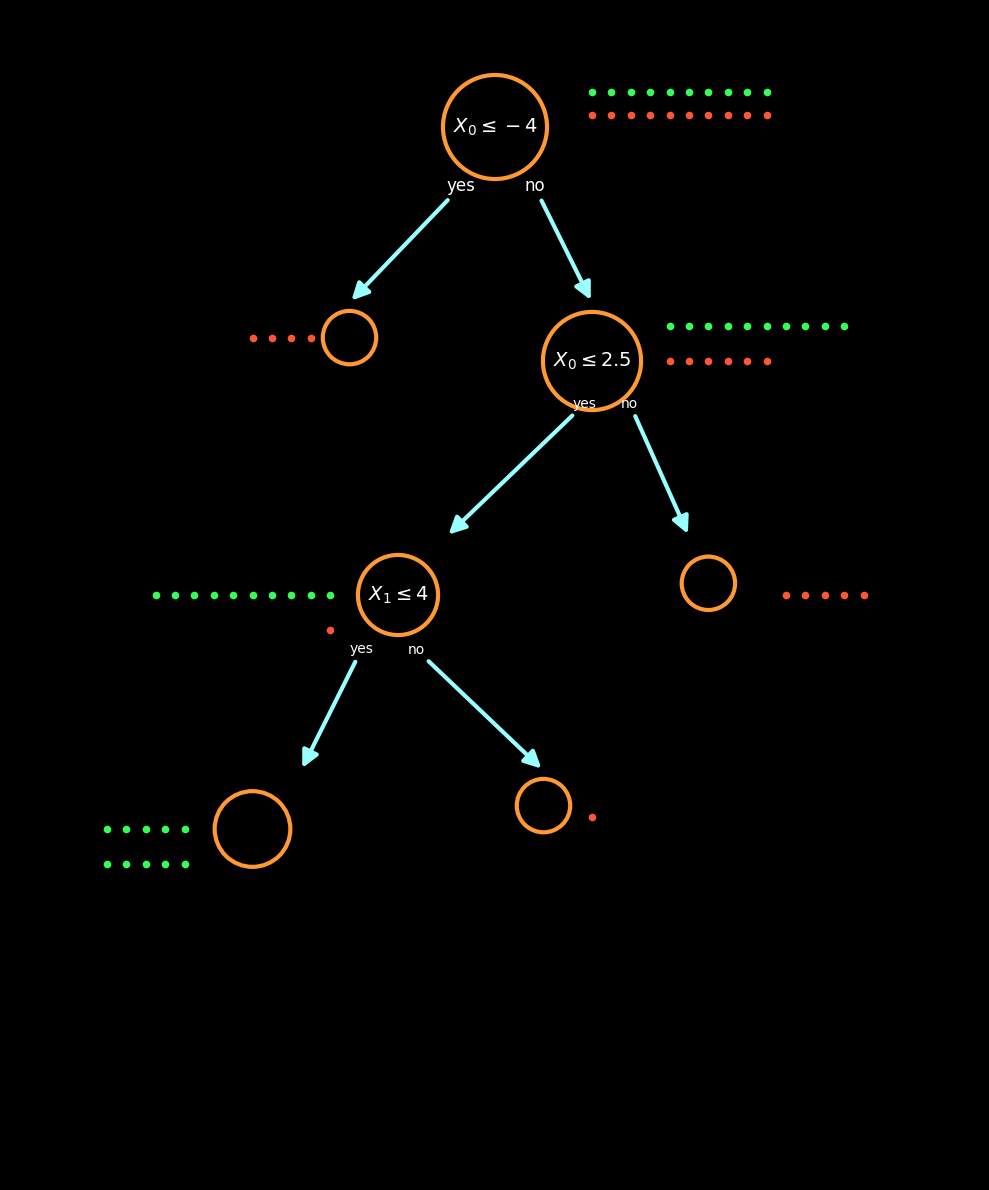

In [137]:
import matplotlib.pyplot as plt

def draw_circular_style_tree():
    # Set dark theme
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 12))
    
    # Node styles: Orange circles
    circle_style = dict(boxstyle="circle,pad=0.5", fc="none", ec="#FF9933", lw=3)
    
    # Define node positions (x, y)
    pos = {
        'root': (0.5, 0.9),
        'L1_left': (0.35, 0.72),
        'L1_right': (0.60, 0.7),
        'L2_left': (0.4, 0.5),
        'L2_right': (0.72, 0.51),
        'L3_left': (0.25, 0.30),
        'L3_right': (0.55, 0.32)
    }

    # 1. Draw Nodes (Empty circles with labels inside or dots above)
    # Root
    ax.text(pos['root'][0], pos['root'][1], "$X_0 \leq -4$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # Visual dots (10 green, 10 red) at the top right of root
    ax.scatter([0.60 + i*0.02 for i in range(10)], [0.93]*10, c='#33FF57', s=20)
    ax.scatter([0.60 + i*0.02 for i in range(10)], [0.91]*10, c='#FF5733', s=20)

    # Branches
    ax.text(pos['L1_right'][0], pos['L1_right'][1], "$X_0 \leq 2.5$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # Visual dots (10 green, 6 red)
    ax.scatter([0.68 + i*0.02 for i in range(10)], [0.73]*10, c='#33FF57', s=20)
    ax.scatter([0.68 + i*0.02 for i in range(6)], [0.7]*6, c='#FF5733', s=20)

    ax.text(pos['L2_left'][0], pos['L2_left'][1], "$X_1 \leq 4$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # Visual dots (10 green, 1 red)
    ax.scatter([0.15+ i*0.02 for i in range(10)], [0.5]*10, c='#33FF57', s=20)
    ax.scatter([0.33 + i*0.02 for i in range(1)], [0.47]*1, c='#FF5733', s=20)

    # Leaf Nodes (Empty circles)
    ax.text(pos['L1_left'][0], pos['L1_left'][1], "       ", ha="center", va="center", bbox=circle_style, fontsize=12)
    ax.scatter([0.25 + i*0.02 for i in range(4)], [0.72]*4, c='#FF5733', s=20)
    
    ax.text(pos['L2_right'][0], pos['L2_right'][1], "       ", ha="center", va="center", bbox=circle_style, fontsize=12)
    ax.scatter([0.80 + i*0.02 for i in range(5)], [0.5]*5, c='#FF5733', s=20)
    

    ax.text(pos['L3_left'][0], pos['L3_left'][1], "         ", ha="center", va="center", bbox=circle_style, fontsize=14)
    #visual dots (10 green)
    ax.scatter([0.10+ i*0.02 for i in range(5)], [0.30]*5, c='#33FF57', s=20)
    ax.scatter([0.10+ i*0.02 for i in range(5)], [0.27]*5, c='#33FF57', s=20)
    

    ax.text(pos['L3_right'][0], pos['L3_right'][1], "       ", ha="center", va="center", bbox=circle_style, fontsize=12)
    # Visual dots (1 red)
    ax.scatter([0.60+ i*0.02 for i in range(1)], [0.31]*1, c='#FF5733', s=20)
    
  

    # 2. Draw Arrows (Cyan/Light Blue)
    arrow_props = dict(arrowstyle="-|>", lw=3, color='#99FFFF', mutation_scale=25)
    yes_arrow = dict(arrowstyle="-|>", lw=3, color='#99FFFF', mutation_scale=25) 

    # Level 1
    ax.annotate("yes", xy=(0.35, 0.75), xytext=(0.45, 0.845), arrowprops=yes_arrow, fontsize=12, color='white')
    ax.annotate("no", xy=(0.60, 0.75), xytext=(0.53, 0.845), arrowprops=arrow_props,fontsize=12, color='white')
    
    # Level 2
    ax.annotate("yes", xy=(0.45, 0.55), xytext=(0.58, 0.66), arrowprops=arrow_props)
    ax.annotate("no", xy=(0.70, 0.55), xytext=(0.63, 0.66), arrowprops=arrow_props)

    # Level 3
    ax.annotate("yes", xy=(0.30, 0.35), xytext=(0.35, 0.45), arrowprops=arrow_props)
    ax.annotate("no", xy=(0.55, 0.35), xytext=(0.41, 0.45), arrowprops=arrow_props)

   
    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('custom_style_tree.png', dpi=300)
    plt.show()

draw_circular_style_tree()

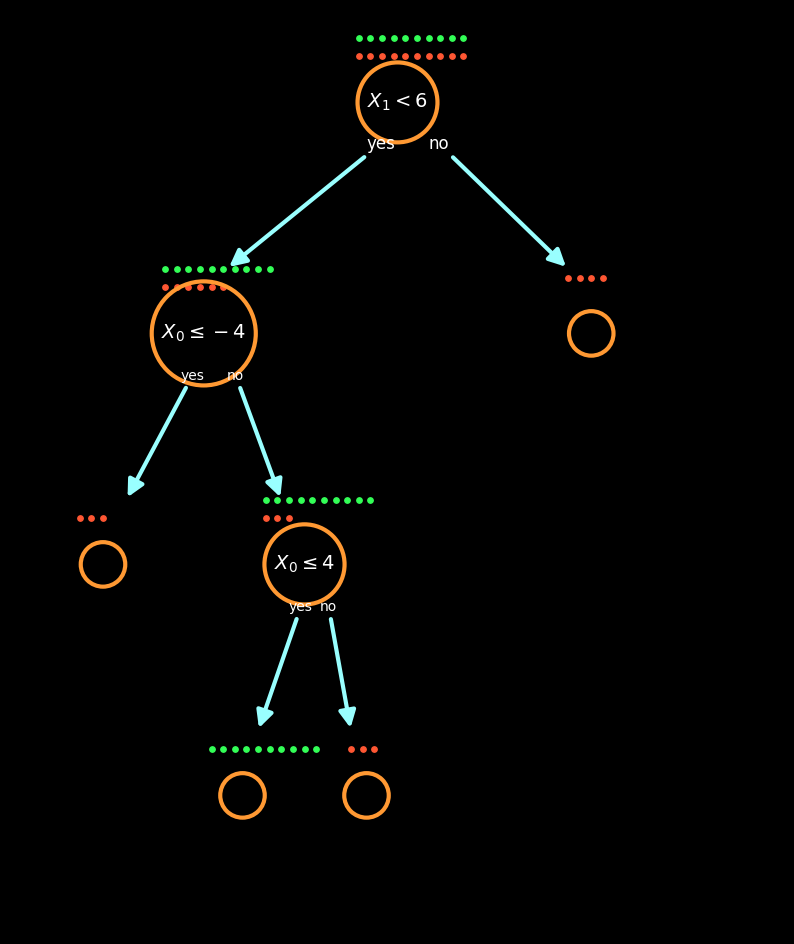

In [140]:
import matplotlib.pyplot as plt

def draw_symmetric_style_tree():
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 12))
    
    circle_style = dict(boxstyle="circle,pad=0.5", fc="none", ec="#FF9933", lw=3)
    
    # New Balanced Positions
    pos = {
        'root': (0.5, 0.9),
        'L1_L': (0.25, 0.65), # Left Branch
        'L1_R': (0.75, 0.65), # Right Branch
        'L2_LL': (0.12, 0.4), # Leaf 1
        'L2_LR': (0.38, 0.4), # Node 2
        'L2_RL': (0.62, 0.4), # Leaf 2
        'L2_RR': (0.88, 0.4), # Leaf 3
        'L3_LRL': (0.30, 0.15), # Final Green Leaf
        'L3_LRR': (0.46, 0.15)  # Final Red Leaf
    }

    # --- ROOT ---
    ax.text(pos['root'][0], pos['root'][1], "$X_1 < 6$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # Total Data: 10 Green, 10 Red
    ax.scatter([0.45 + i*0.015 for i in range(10)], [0.97]*10, c='#33FF57', s=15)
    ax.scatter([0.45 + i*0.015 for i in range(10)], [0.95]*10, c='#FF5733', s=15)

    # --- LEVEL 1 ---
    # Left: X1 <= 6
    ax.text(pos['L1_L'][0], pos['L1_L'][1], "$X_0 \leq -4$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # 10 Green, 6 Red left
    ax.scatter([0.20 + i*0.015 for i in range(10)], [0.72]*10, c='#33FF57', s=15)
    ax.scatter([0.20 + i*0.015 for i in range(6)], [0.70]*6, c='#FF5733', s=15)

    # Right: X1 > 6 (Purely Red top cluster)
    ax.text(pos['L1_R'][0], pos['L1_R'][1], "       ", ha="center", va="center", bbox=circle_style)
    # 4 Red points isolated
    ax.scatter([0.72 + i*0.015 for i in range(4)], [0.71]*4, c='#FF5733', s=15)

    # --- LEVEL 2 ---
    # Left-Left: X0 <= -4 (Purely Red left cluster)
    ax.text(pos['L2_LL'][0], pos['L2_LL'][1], "       ", ha="center", va="center", bbox=circle_style)
    ax.scatter([0.09 + i*0.015 for i in range(3)], [0.45]*3, c='#FF5733', s=15)

    # Left-Right: X0 > -4 (The core area)
    ax.text(pos['L2_LR'][0], pos['L2_LR'][1], "$X_0 \leq 4$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # 10 Green, 3 Red left
    ax.scatter([0.33 + i*0.015 for i in range(10)], [0.47]*10, c='#33FF57', s=15)
    ax.scatter([0.33 + i*0.015 for i in range(3)], [0.45]*3, c='#FF5733', s=15)

    # --- LEVEL 3 ---
    # The Success Leaf: The Center Box
    ax.text(pos['L3_LRL'][0], pos['L3_LRL'][1], "       ", ha="center", va="center", bbox=circle_style)
    ax.scatter([0.26 + i*0.015 for i in range(10)], [0.2]*10, c='#33FF57', s=15)

    # The Failure Leaf: Right-side Red points
    ax.text(pos['L3_LRR'][0], pos['L3_LRR'][1], "       ", ha="center", va="center", bbox=circle_style)
    ax.scatter([0.44 + i*0.015 for i in range(3)], [0.2]*3, c='#FF5733', s=15)

    # --- ARROWS ---
    arrow_props = dict(arrowstyle="-|>", lw=3, color='#99FFFF', mutation_scale=25)
    
    # Root to L1
    ax.annotate("yes", xy=(0.28, 0.72), xytext=(0.46, 0.85), arrowprops=arrow_props, fontsize=12)
    ax.annotate("no", xy=(0.72, 0.72), xytext=(0.54, 0.85), arrowprops=arrow_props, fontsize=12)
    
    # L1_L to L2
    ax.annotate("yes", xy=(0.15, 0.47), xytext=(0.22, 0.60), arrowprops=arrow_props)
    ax.annotate("no", xy=(0.35, 0.47), xytext=(0.28, 0.60), arrowprops=arrow_props)
    
    # L2_LR to L3
    ax.annotate("yes", xy=(0.32, 0.22), xytext=(0.36, 0.35), arrowprops=arrow_props)
    ax.annotate("no", xy=(0.44, 0.22), xytext=(0.40, 0.35), arrowprops=arrow_props)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.savefig('custom_style_tree_2.png', dpi=300)
    plt.show()

draw_symmetric_style_tree()

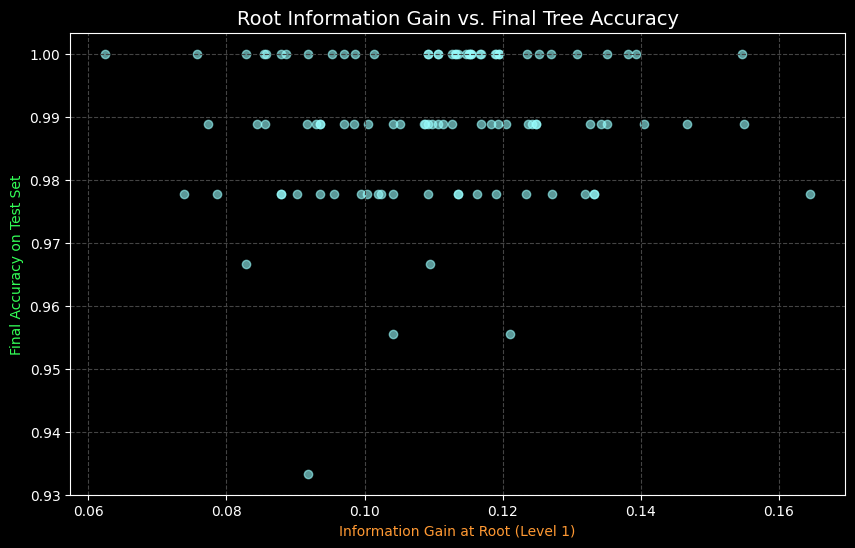

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Generate the Circular Data
np.random.seed(42)
def generate_data(n=200):
    X = np.random.uniform(-10, 10, (n, 2))
    # Classify as Green (1) if inside a center square, else Red (0)
    y = ((X[:, 0] > -4) & (X[:, 0] < 4) & (X[:, 1] > -4) & (X[:, 1] < 4)).astype(int)
    return X, y

# 2. Simulation
ig_scores = []
accuracy_scores = []

for i in range(100):
    X, y = generate_data(300)
    # Shuffle/Resample to create 100 different "perspectives"
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
    
    # Train a tree
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=5)
    clf.fit(X_train, y_train)
    
    # Extract the Entropy of the root and its children to manually get IG
    root_entropy = clf.tree_.impurity[0]
    n_total = clf.tree_.n_node_samples[0]
    left_child_entropy = clf.tree_.impurity[1]
    n_left = clf.tree_.n_node_samples[1]
    right_child_entropy = clf.tree_.impurity[2]
    n_right = clf.tree_.n_node_samples[2]
    
    ig = root_entropy - ((n_left/n_total)*left_child_entropy + (n_right/n_total)*right_child_entropy)
    
    # Get Final Accuracy
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    ig_scores.append(ig)
    accuracy_scores.append(acc)

# 3. Plotting the Relationship
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.scatter(ig_scores, accuracy_scores, color='#99FFFF', alpha=0.6)
plt.title("Root Information Gain vs. Final Tree Accuracy", fontsize=14)
plt.xlabel("Information Gain at Root (Level 1)", color='#FF9933')
plt.ylabel("Final Accuracy on Test Set", color='#33FF57')
plt.savefig('decision_tree_100.png', dpi=300)
plt.grid(color='#444', linestyle='--')
plt.show()

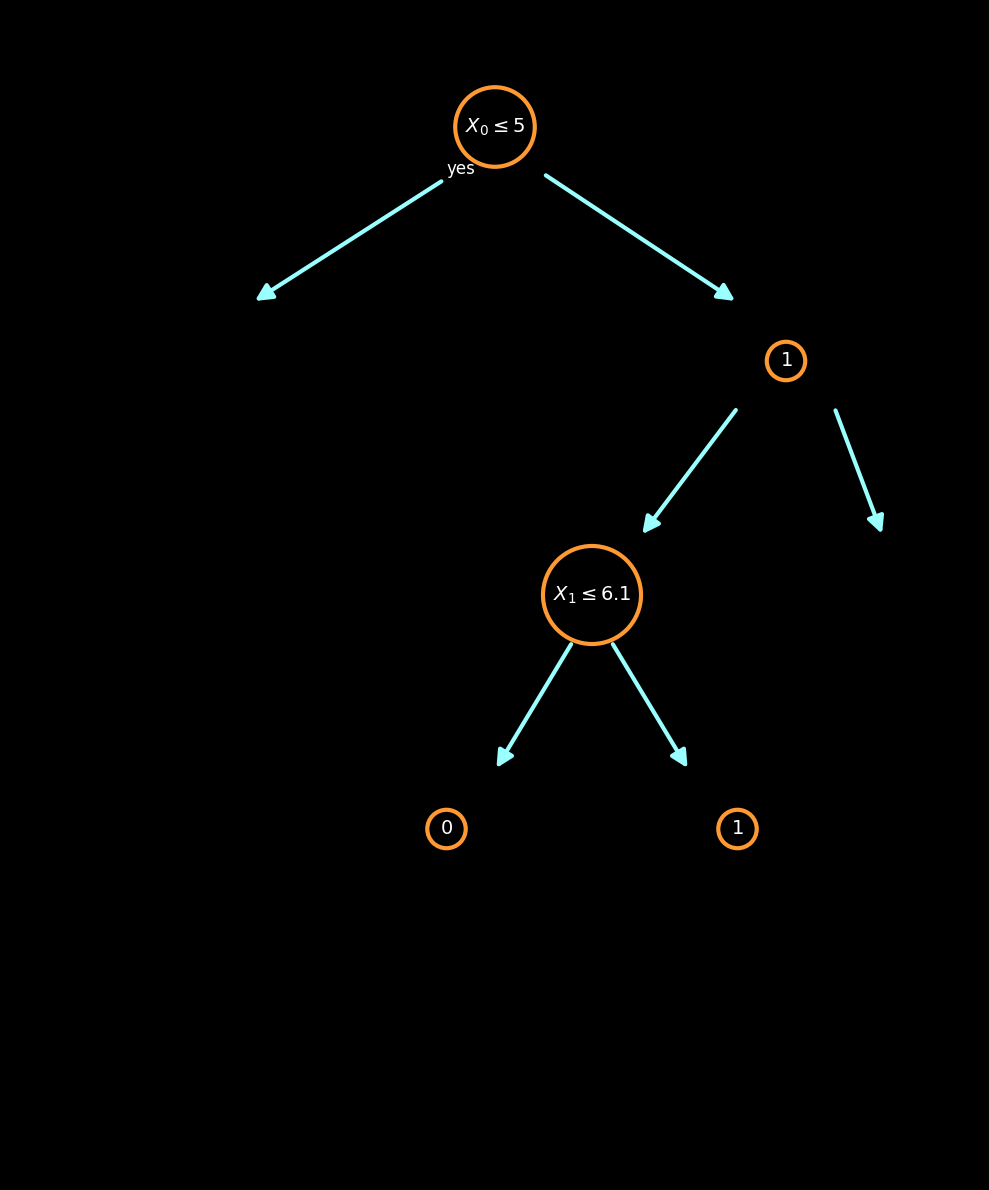

In [147]:
def draw_circular_style_tree_3():
    # Set dark theme
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 12))
    
    # Node styles: Orange circles
    circle_style = dict(boxstyle="circle,pad=0.5", fc="none", ec="#FF9933", lw=3)
    
    # Define node positions (x, y)
    pos = {
        'root': (0.5, 0.9),
        'L1_left': (0.2, 0.7),
        'L1_right': (0.8, 0.7),
        'L2_left': (0.6, 0.5),
        'L2_right': (0.95, 0.5),
        'L3_left': (0.45, 0.3),
        'L3_right': (0.75, 0.3),
        
    }

    # 1. Draw Nodes (Empty circles with labels inside or dots above)
    # Root
    ax.text(pos['root'][0], pos['root'][1], "$X_0 \leq 5$", ha="center", va="center", bbox=circle_style, fontsize=14)
    # ax.scatter([0.65 + i*0.02 for i in range(10)], [0.93]*10, c='#33FF57', s=20)
    # ax.scatter([0.65 + i*0.02 for i in range(10)], [0.91]*10, c='#FF5733', s=20)

    # Branches
    ax.text(pos['L1_right'][0], pos['L1_right'][1], "$1$", ha="center", va="center", bbox=circle_style, fontsize=14)
    ax.text(pos['L2_left'][0], pos['L2_left'][1], "$X_1 \leq 6.1$", ha="center", va="center", bbox=circle_style, fontsize=14)
    ax.text(pos['L3_left'][0], pos['L3_left'][1], "$0$", ha="center", va="center", bbox=circle_style, fontsize=14)
    ax.text(pos['L3_right'][0], pos['L3_right'][1], "$1$", ha="center", va="center", bbox=circle_style, fontsize=14)

   
    # 2. Draw Arrows (Cyan/Light Blue)
    arrow_props = dict(arrowstyle="-|>", lw=3, color='#99FFFF', mutation_scale=25)
    yes_arrow = dict(arrowstyle="-|>", lw=3, color='#FFFF33', mutation_scale=25) # Yellow for 'yes'

    # Level 1
    ax.annotate("yes", xy=(0.25, 0.75), xytext=(0.45, 0.86), arrowprops=arrow_props, fontsize=12, color='white')
    ax.annotate("", xy=(0.75, 0.75), xytext=(0.55, 0.86), arrowprops=arrow_props)
    
    # Level 2
    ax.annotate("", xy=(0.65, 0.55), xytext=(0.75, 0.66), arrowprops=arrow_props)
    ax.annotate("", xy=(0.9, 0.55), xytext=(0.85, 0.66), arrowprops=arrow_props)

    # Level 3
    ax.annotate("", xy=(0.5, 0.35), xytext=(0.58, 0.46), arrowprops=arrow_props)
    ax.annotate("", xy=(0.7, 0.35), xytext=(0.62, 0.46), arrowprops=arrow_props)


    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('custom_style_tree_3.png', dpi=300)
    plt.show()

draw_circular_style_tree_3()

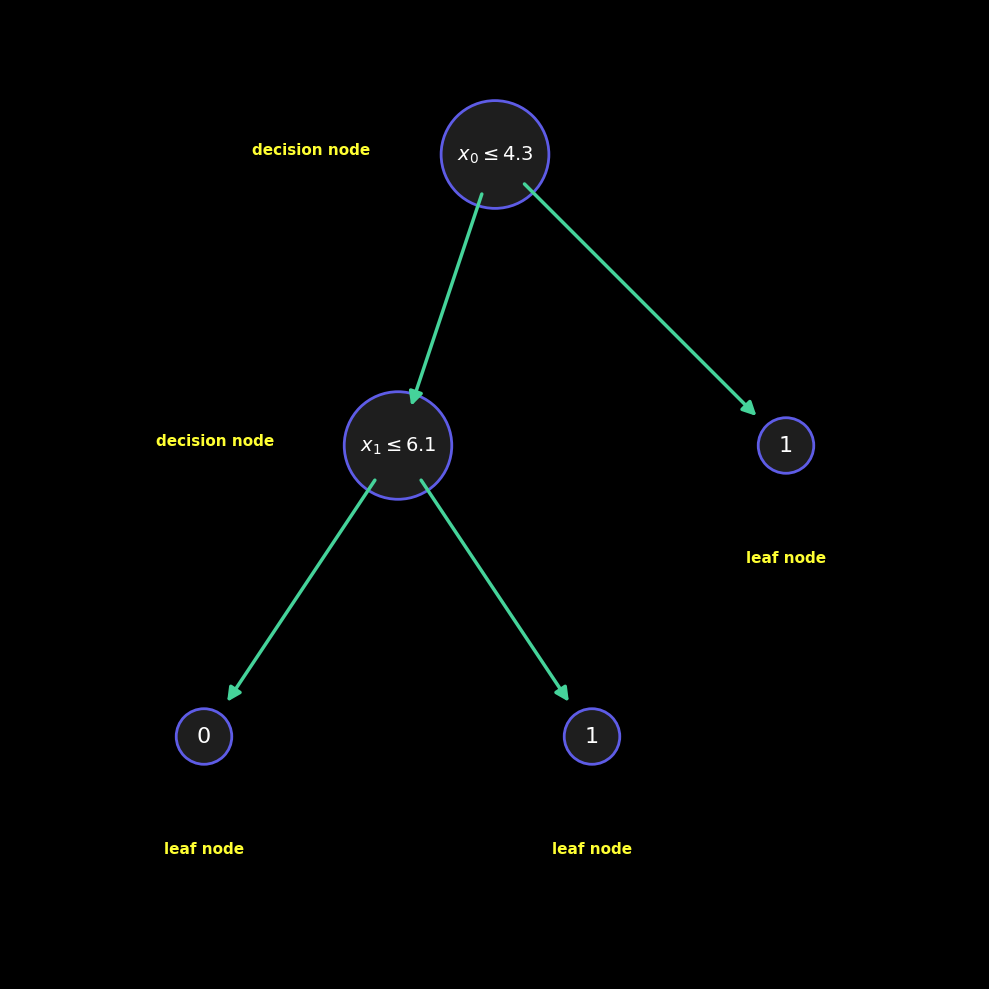

In [149]:
import matplotlib.pyplot as plt

def draw_circular_style_tree_final():
    # Set dark theme to match your image
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Node styles: Consistent purple-bordered circles
    # fc="none" keeps them hollow like the image
    circle_style = dict(boxstyle="circle,pad=0.8", fc="#1e1e1e", ec="#5e5ce6", lw=2)
    
    # Define node positions (x, y) to match the vertical flow
    pos = {
        'root': (0.5, 0.85),       # Level 0
        'L1_right': (0.8, 0.55),   # Level 1 Leaf
        'L1_left': (0.4, 0.55),    # Level 1 Decision
        'L2_left': (0.2, 0.25),    # Level 2 Leaf (0)
        'L2_right': (0.6, 0.25)    # Level 2 Leaf (1)
    }

    # 1. Draw Nodes
    # Root Decision
    ax.text(pos['root'][0], pos['root'][1], "$x_0 \leq 4.3$", ha="center", va="center", bbox=circle_style, fontsize=14, color="white")
    ax.text(pos['root'][0]-0.25, pos['root'][1], "decision node", color="#ffff33", fontweight='bold', fontsize=11)

    # Level 1 Decision
    ax.text(pos['L1_left'][0], pos['L1_left'][1], "$x_1 \leq 6.1$", ha="center", va="center", bbox=circle_style, fontsize=14, color="white")
    ax.text(pos['L1_left'][0]-0.25, pos['L1_left'][1], "decision node", color="#ffff33", fontweight='bold', fontsize=11)

    # Leaves
    leaves = [
        ('L1_right', '1'),
        ('L2_left', '0'),
        ('L2_right', '1')
    ]
    for key, label in leaves:
        ax.text(pos[key][0], pos[key][1], label, ha="center", va="center", bbox=circle_style, fontsize=16, color="white")
        ax.text(pos[key][0], pos[key][1]-0.12, "leaf node", color="#ffff33", fontweight='bold', fontsize=11, ha="center")

    # 2. Draw Arrows (Cyan style from image)
    arrow_props = dict(arrowstyle="-|>", lw=2.5, color='#45d39a', mutation_scale=20, shrinkA=30, shrinkB=30)

    # Root to Level 1
    ax.annotate("", xy=pos['L1_left'], xytext=pos['root'], arrowprops=arrow_props)
    ax.annotate("", xy=pos['L1_right'], xytext=pos['root'], arrowprops=arrow_props)
    
    # Level 1 to Level 2
    ax.annotate("", xy=pos['L2_left'], xytext=pos['L1_left'], arrowprops=arrow_props)
    ax.annotate("", xy=pos['L2_right'], xytext=pos['L1_left'], arrowprops=arrow_props)

    # Formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('replicated_tree_style.png', dpi=300)
    plt.show()

draw_circular_style_tree_final()

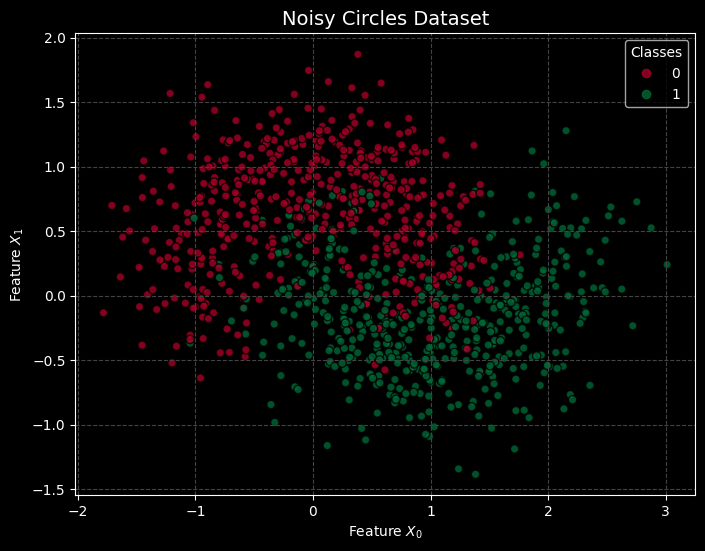

In [223]:
from sklearn.datasets import make_moons,make_circles

# 1. Generate the data
X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)

# 2. Plotting
plt.style.use('dark_background')
plt.figure(figsize=(8, 6))

# c=y assigns colors based on the class (0 or 1)
# cmap='RdYlGn' gives you a nice Red/Green contrast
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolors='k', alpha=0.8)

plt.title("Noisy Circles Dataset", fontsize=14)
plt.xlabel("Feature $X_0$")
plt.ylabel("Feature $X_1$")
plt.grid(color='#444', linestyle='--')

# Add a legend
plt.legend(*scatter.legend_elements(), title="Classes")
plt.savefig("make_circles.png", dpi=300)

plt.show()

In [226]:
## Decision tree vs Random forest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 2. Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)# random_state=42)

# 3. Train a single Decision Tree (prone to memorizing noise)
dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
dt_train_acc = accuracy_score(y_train, dt.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt.predict(X_test))

# 4. Train a Random Forest (uses Bagging to ignore noise)
rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
rf.fit(X_train, y_train)
rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"--- Decision Tree ---")
print(f"Train Accuracy: {dt_train_acc:.4f}")
print(f"Test Accuracy:  {dt_test_acc:.4f}")

print(f"\n--- Random Forest ---")
print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Test Accuracy:  {rf_test_acc:.4f}")

--- Decision Tree ---
Train Accuracy: 1.0000
Test Accuracy:  0.8233

--- Random Forest ---
Train Accuracy: 1.0000
Test Accuracy:  0.8933


In [214]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 1. 100 "Identical" Trees (No randomness)
# We force them to be the same by not using bagging or feature sampling
identical_trees = BaggingClassifier(estimator=DecisionTreeClassifier(), 
                                     n_estimators=100, 
                                     bootstrap=False, 
                                     max_samples=1.0).fit(X_train, y_train)

# 2. 100 "Random Forest" Trees
rf_trees = RandomForestClassifier(n_estimators=100).fit(X_train, y_train)

print(f"100 Identical Trees Accuracy: {identical_trees.score(X_test, y_test):.4f}")
print(f"100 Random Forest Accuracy:  {rf_trees.score(X_test, y_test):.4f}")

100 Identical Trees Accuracy: 0.6833
100 Random Forest Accuracy:  0.7633


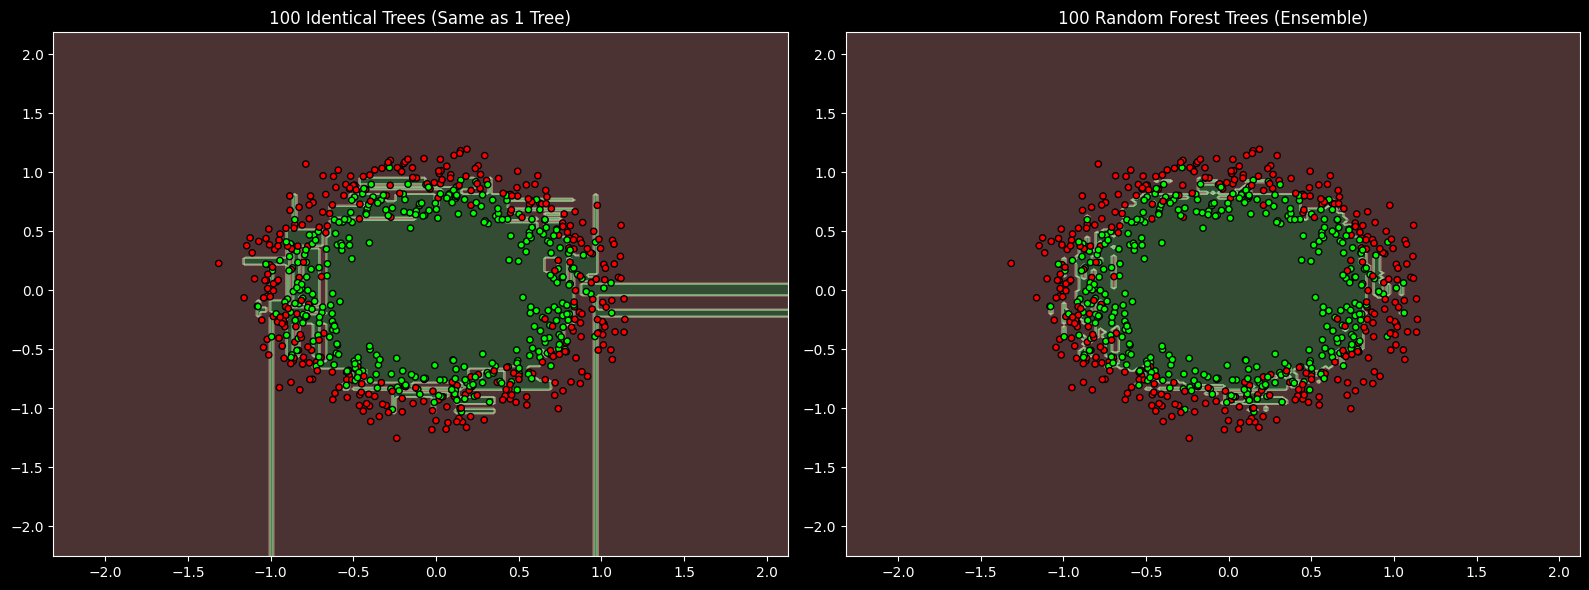

In [215]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, ax, title):
    # Create a mesh grid
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Predict over the grid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot contour and training points
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])
    
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_title(title)

# Create the comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(identical_trees, X_train, y_train, ax1, "100 Identical Trees (Same as 1 Tree)")
plot_decision_boundary(rf_trees, X_train, y_train, ax2, "100 Random Forest Trees (Ensemble)")

plt.tight_layout()
plt.show()

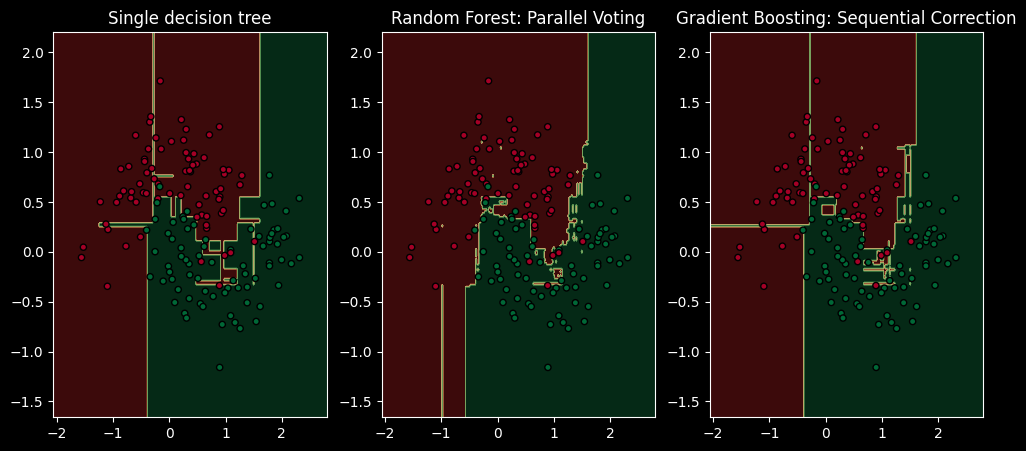

Decision tree test Accuracy:     0.9133
Random Forest test Accuracy:     0.9200
Gradient Boosting test Accuracy:  0.9267
Improvement GB over RF:                0.72%


In [278]:
from sklearn.ensemble import GradientBoostingClassifier

# 1. Setup Data
X, y = make_moons(n_samples=500, noise=0.30)#, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)#, random_state=42)

# 2. Initialize the models
#Decision tree
dt = DecisionTreeClassifier(criterion='entropy')#, random_state=42)

# Random Forest: Focuses on variance reduction through bagging
rf = RandomForestClassifier(n_estimators=100)#, random_state=42)

# Gradient Boosting: Focuses on bias reduction through sequential correction
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)#, random_state=42)

# 3. Train and Predict
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# 4. Calculate Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)

# 3. Visualization logic (Simplified)
def plot_boundary(clf, ax, title):
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlGn', edgecolor='k', s=20)
    ax.set_title(title)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
plot_boundary(dt, ax1, "Single decision tree")
plot_boundary(rf, ax2, "Random Forest: Parallel Voting")
plot_boundary(gb, ax3, "Gradient Boosting: Sequential Correction")
plt.show()

print(f"Decision tree test Accuracy:     {dt_acc:.4f}")
print(f"Random Forest test Accuracy:     {rf_acc:.4f}")
print(f"Gradient Boosting test Accuracy:  {gb_acc:.4f}")
print(f"Improvement GB over RF:                {((gb_acc - rf_acc) / rf_acc) * 100:.2f}%")

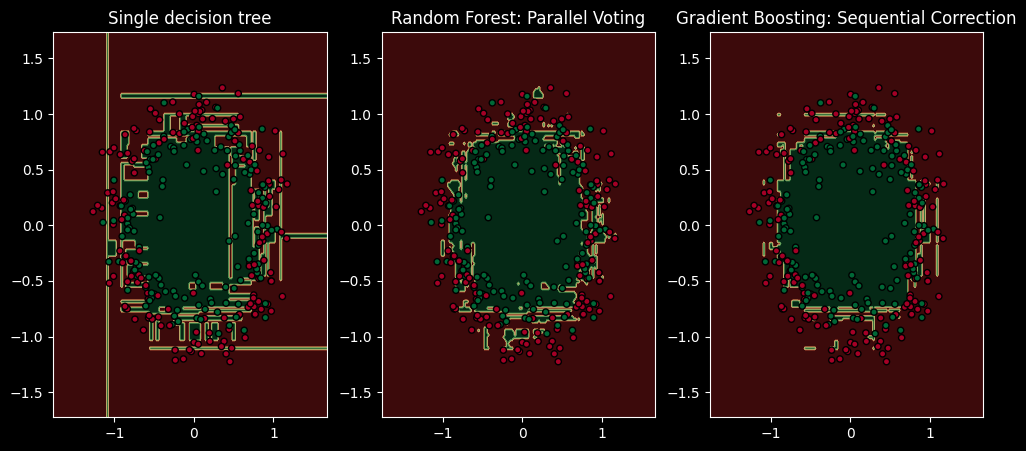

Decision tree test Accuracy:     0.6500
Random Forest test Accuracy:     0.6867
Gradient Boosting test Accuracy:  0.6933
Improvement GB over RF:                0.97%


In [280]:
# 1. Setup Data
X, y = make_circles(n_samples=1000, noise=0.16)#, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)#, random_state=42)

# 2. Initialize the models
#Decision tree
dt = DecisionTreeClassifier(criterion='entropy')#, random_state=42)

# Random Forest: Focuses on variance reduction through bagging
rf = RandomForestClassifier(n_estimators=100)#, random_state=42)

# Gradient Boosting: Focuses on bias reduction through sequential correction
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)#, random_state=42)

# 3. Train and Predict
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

# 4. Calculate Accuracy
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)
gb_acc = accuracy_score(y_test, gb_pred)

# 3. Visualization logic (Simplified)
def plot_boundary(clf, ax, title):
    x_min, x_max = X_test[:, 0].min() - 0.5, X_test[:, 0].max() + 0.5
    y_min, y_max = X_test[:, 1].min() - 0.5, X_test[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlGn', edgecolor='k', s=20)
    ax.set_title(title)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
plot_boundary(dt, ax1, "Single decision tree")
plot_boundary(rf, ax2, "Random Forest: Parallel Voting")
plot_boundary(gb, ax3, "Gradient Boosting: Sequential Correction")
plt.show()

print(f"Decision tree test Accuracy:     {dt_acc:.4f}")
print(f"Random Forest test Accuracy:     {rf_acc:.4f}")
print(f"Gradient Boosting test Accuracy:  {gb_acc:.4f}")
print(f"Improvement GB over RF:                {((gb_acc - rf_acc) / rf_acc) * 100:.2f}%")

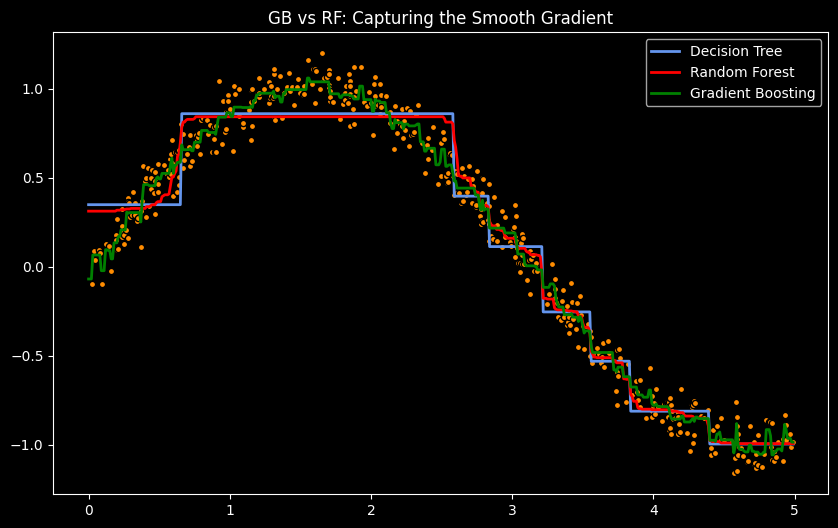

Decision Tree R2 Score:  0.9721,              Decision Tree MSE:      0.014113 
Random Forest R2 Score:   0.9800,             Random Forest MSE:      0.010113
Gradient Boosting R2 Score:  0.9973,          Gradient Boosting MSE:  0.001384
Improved accuracy of GB over RF:      1.76%
Improved error of GB over RF:      86.32%


In [308]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


# 1. Create a dataset with a very specific, smooth pattern
N=500
X = np.sort(5 * np.random.rand(N, 1), axis=0)
y = np.sin(X).ravel()

# 2. Add almost NO noise (This is where GB shines)
y += 0.09 * np.random.randn(len(X)) 

# 3. Train Models
dt = DecisionTreeRegressor(max_depth=3).fit(X, y)
rf = RandomForestRegressor(n_estimators=100, max_depth=3).fit(X, y)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3).fit(X, y)

# 4. Predict
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_test= np.sin(X_test).ravel() #flatten()
y_dt = dt.predict(X_test)
y_rf = rf.predict(X_test)
y_gb = gb.predict(X_test)

# 5. Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange")#, label="data")
plt.plot(X_test, y_dt, color="cornflowerblue", label="Decision Tree", linewidth=2)
plt.plot(X_test, y_rf, color="red", label="Random Forest", linewidth=2)
plt.plot(X_test, y_gb, color="green", label="Gradient Boosting", linewidth=2)
plt.title("GB vs RF: Capturing the Smooth Gradient")
plt.legend()
plt.show()



# 6. Calculate R2 Score (Coefficient of Determination) and MSE
# This is the "Accuracy" equivalent for regression.
dt_r2 = r2_score(y_test, y_dt)
rf_r2 = r2_score(y_test, y_rf)
gb_r2 = r2_score(y_test, y_gb)

dt_mse = mean_squared_error(y_test, y_dt)
rf_mse = mean_squared_error(y_test, y_rf)
gb_mse = mean_squared_error(y_test, y_gb)



# Calculate improvement (since lower error is better)
improvement_mse = ((rf_mse - gb_mse) / rf_mse) * 100
#print(f"Error Reduction (GB vs RF): {improvement_mse:.2f}%")

print(f"Decision Tree R2 Score:  {dt_r2:.4f},              Decision Tree MSE:      {dt_mse:.6f} ")
print(f"Random Forest R2 Score:   {rf_r2:.4f},             Random Forest MSE:      {rf_mse:.6f}")
print(f"Gradient Boosting R2 Score:  {gb_r2:.4f},          Gradient Boosting MSE:  {gb_mse:.6f}")

# Since higher R2 is better:
improvement = ((gb_r2 - rf_r2) / abs(rf_r2)) * 100
print(f"Improved accuracy of GB over RF:      {improvement:.2f}%")
print(f"Improved error of GB over RF:      {improvement_mse:.2f}%")